# Preprocessing Data
Pembersihan data, penambahan fitur teknikal, pemisahan data (split), normalisasi, dan pembuatan window untuk LSTM.

## 1. Setup & Import

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
import matplotlib.pyplot as plt
import pickle
import warnings

warnings.filterwarnings('ignore')

LOOKBACK = 60
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DATA_RAW = '../data/raw/data_antam.csv'
DATA_PROCESSED = '../data/processed/data_antam_clean.csv'

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)


## 2. Load & Sort Data
Load CSV, set index Tanggal, dan pastikan terurut ascending.

In [11]:
df = pd.read_csv(DATA_RAW)

df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')
df.set_index('Tanggal', inplace=True)

df.sort_index(ascending=True, inplace=True)

display(df.head())

,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
Tanggal,,,,,,
2014-01-01,916.0,916.0,941.0,916.0,"18,16M","0,00%"
2014-01-02,907.0,916.0,932.0,907.0,"15,86M","-0,98%"
2014-01-03,874.0,907.0,907.0,857.0,"24,57M","-3,64%"
2014-01-06,844.0,865.0,882.0,844.0,"17,89M","-3,43%"
2014-01-07,844.0,840.0,844.0,798.0,"21,26M","0,00%"


## 3. Koreksi Harga (KRITIS)
Koreksi kesalahan baca pemisah ribuan titik pada pandas.

Koreksi 1435 baris pada kolom Terakhir
Koreksi 1436 baris pada kolom Pembukaan
Koreksi 1456 baris pada kolom Tertinggi
Koreksi 1414 baris pada kolom Terendah


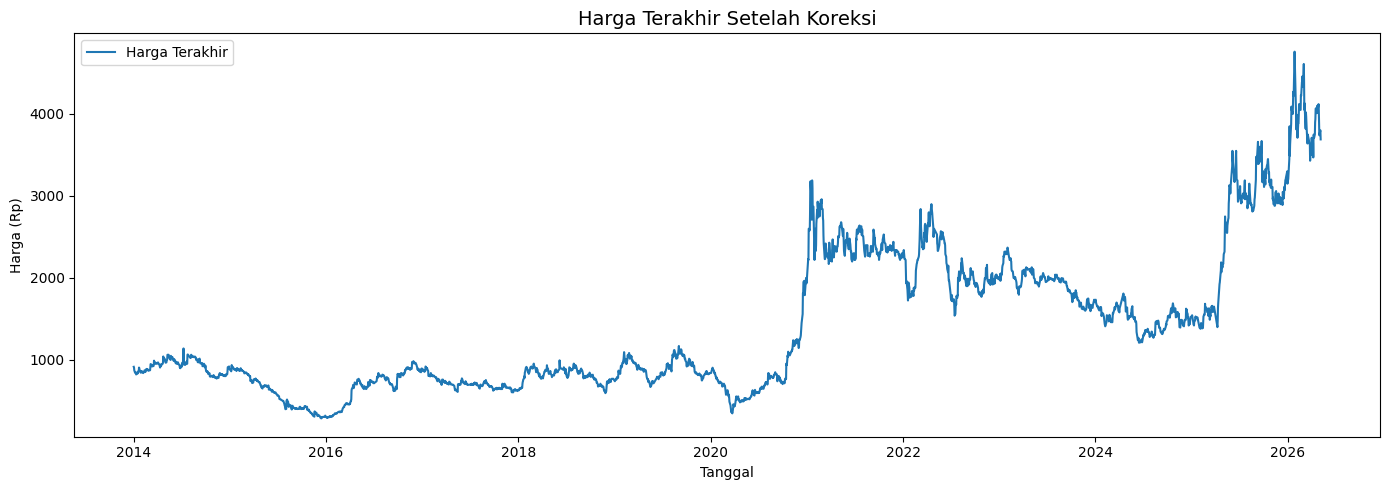

In [12]:
price_cols = ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah']

# Pastikan data berupa numerik, tangani koma jika ada
for col in price_cols:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Koreksi masing-masing kolom secara independen
for col in price_cols:
    mask = df[col] < 10
    if mask.sum() > 0:
        print(f"Koreksi {mask.sum()} baris pada kolom {col}")
        df.loc[mask, col] = df.loc[mask, col] * 1000

# Plot untuk memastikan tidak ada gap
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Terakhir'], label='Harga Terakhir')
plt.title('Harga Terakhir Setelah Koreksi', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Parse Kolom String
Mengubah kolom `Vol.` dan `Perubahan%` menjadi numerik (float).

In [13]:
def parse_vol(val):
    if pd.isna(val) or val == '-':
        return 0.0
    val_str = str(val).upper().replace(',', '.')
    if 'M' in val_str:
        return float(val_str.replace('M', '')) * 1e6
    if 'K' in val_str:
        return float(val_str.replace('K', '')) * 1e3
    if 'B' in val_str:
        return float(val_str.replace('B', '')) * 1e9
    return float(val_str)

df['Vol.'] = df['Vol.'].apply(parse_vol)

def parse_change(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).replace('%', '').replace(',', '.')
    return float(val_str) / 100.0

df['Perubahan%'] = df['Perubahan%'].apply(parse_change)

display(df.dtypes)
display(df.head())

Terakhir      float64
Pembukaan     float64
Tertinggi     float64
Terendah      float64
Vol.          float64
Perubahan%    float64
dtype: object

,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
Tanggal,,,,,,
2014-01-01,916.0,916.0,941.0,916.0,18160000.0,0.0000
2014-01-02,907.0,916.0,932.0,907.0,15860000.0,-0.0098
2014-01-03,874.0,907.0,907.0,857.0,24570000.0,-0.0364
2014-01-06,844.0,865.0,882.0,844.0,17890000.0,-0.0343
2014-01-07,844.0,840.0,844.0,798.0,21260000.0,0.0000


## 5. Tambahkan Fitur Teknikal
Menambahkan MA7, MA30, RSI (14), dan Bollinger Bands (Upper, Lower, Width).

In [14]:
print(f"Shape sebelum drop NaN: {df.shape}")

# Moving Averages
df['MA7'] = df['Terakhir'].rolling(window=7).mean()
df['MA30'] = df['Terakhir'].rolling(window=30).mean()

# RSI (14)
delta = df['Terakhir'].diff()
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = (-delta.clip(upper=0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands
ma20 = df['Terakhir'].rolling(window=20).mean()
std20 = df['Terakhir'].rolling(window=20).std()
df['BB_upper'] = ma20 + (2 * std20)
df['BB_lower'] = ma20 - (2 * std20)
df['BB_width'] = df['BB_upper'] - df['BB_lower']

# Drop baris NaN akibat rolling window
df.dropna(inplace=True)

print(f"Shape setelah drop NaN: {df.shape}")

Shape sebelum drop NaN: (2982, 6)
Shape setelah drop NaN: (2953, 12)


## 6. Simpan Data Cleaned
Menyimpan data sebelum dinormalisasi.

In [15]:
df.to_csv(DATA_PROCESSED)
print(f"Data Cleaned tersimpan di: {DATA_PROCESSED}")

Data Cleaned tersimpan di: ../data/processed/data_antam_clean.csv


## 7. Split Data (Kronologis)
Pembagian data menjadi Train (80%), Validation (10%), Test (10%).

In [16]:
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train : {train_df.index[0].strftime('%Y-%m-%d')} -> {train_df.index[-1].strftime('%Y-%m-%d')} ({len(train_df)} baris)")
print(f"Val   : {val_df.index[0].strftime('%Y-%m-%d')} -> {val_df.index[-1].strftime('%Y-%m-%d')} ({len(val_df)} baris)")
print(f"Test  : {test_df.index[0].strftime('%Y-%m-%d')} -> {test_df.index[-1].strftime('%Y-%m-%d')} ({len(test_df)} baris)")

Train : 2014-02-13 -> 2023-11-01 (2362 baris)
Val   : 2023-11-02 -> 2025-01-30 (295 baris)
Test  : 2025-01-31 -> 2026-05-05 (296 baris)


## 8. Normalisasi
MinMaxScaler fit pada data latih saja (Train), kemudian diaplikasikan pada Train, Val, dan Test untuk mencegah data leakage.

In [17]:
features = ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah', 'Vol.',
            'MA7', 'MA30', 'RSI', 'BB_upper', 'BB_lower', 'BB_width']
target = 'Terakhir'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya di train
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[target]])

# Transform ke semua split
train_X_scaled = scaler_X.transform(train_df[features])
train_y_scaled = scaler_y.transform(train_df[[target]])

val_X_scaled = scaler_X.transform(val_df[features])
val_y_scaled = scaler_y.transform(val_df[[target]])

test_X_scaled = scaler_X.transform(test_df[features])
test_y_scaled = scaler_y.transform(test_df[[target]])

# Simpan scaler
with open('../models/scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('../models/scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

print("Scaler tersimpan di direktori models/ (scaler_X.pkl dan scaler_y.pkl)")

Scaler tersimpan di direktori models/ (scaler_X.pkl dan scaler_y.pkl)


## 9. Buat Sliding Window Sequences untuk LSTM
Membuat sequence berdasarkan LOOKBACK window.

In [18]:
def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:(i + lookback)])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_sequences(train_X_scaled, train_y_scaled.flatten(), LOOKBACK)
X_val, y_val = create_sequences(val_X_scaled, val_y_scaled.flatten(), LOOKBACK)
X_test, y_test = create_sequences(test_X_scaled, test_y_scaled.flatten(), LOOKBACK)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

# Simpan arrays
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_test.npy', y_test)

print("Semua array sequence tersimpan di data/processed/ (.npy)")

X_train: (2302, 60, 11), y_train: (2302,)
X_val  : (235, 60, 11), y_val  : (235,)
X_test : (236, 60, 11), y_test : (236,)
Semua array sequence tersimpan di data/processed/ (.npy)
